<a href="https://colab.research.google.com/github/JuliaVillaVerde/Processamentos-de-Sinais-7P./blob/main/Aula_4_Processamento_de_Sinais.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Questão 1


## 1. Defining the signal and its DTFT

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Define the signal x[n] = δ[n] − δ[n − 1] + δ[n − 2] − δ[n − 3]
# The signal is non-zero only for n = 0, 1, 2, 3.
# We can represent it as an array.
x = np.array([1, -1, 1, -1])

# Define a range for omega (frequency) for DTFT
omega = np.linspace(-np.pi, np.pi, 1000) # From -pi to pi for continuous frequency

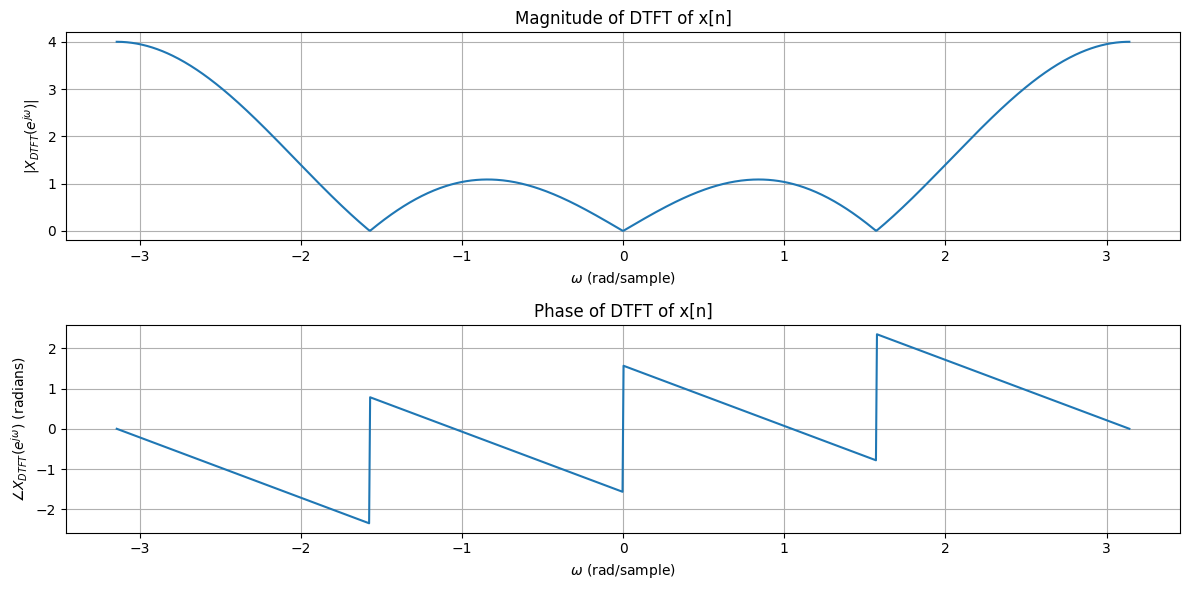

In [18]:
# Calculate the DTFT of x[n]
X_dtft = np.zeros_like(omega, dtype=complex)
for k, w in enumerate(omega):
    for n in range(len(x)):
        X_dtft[k] += x[n] * np.exp(-1j * w * n)

# Plot the magnitude and phase of the DTFT
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(omega, np.abs(X_dtft))
plt.title('Magnitude of DTFT of x[n]')
plt.xlabel(r'$\omega$ (rad/sample)')
plt.ylabel(r'$|X_{DTFT}(e^{j\omega})|$')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(omega, np.angle(X_dtft))
plt.title('Phase of DTFT of x[n]')
plt.xlabel(r'$\omega$ (rad/sample)')
plt.ylabel(r'$\angle X_{DTFT}(e^{j\omega})$ (radians)')
plt.grid(True)

plt.tight_layout()
plt.show()

## 2. Calculating and comparing DFT with DTFT

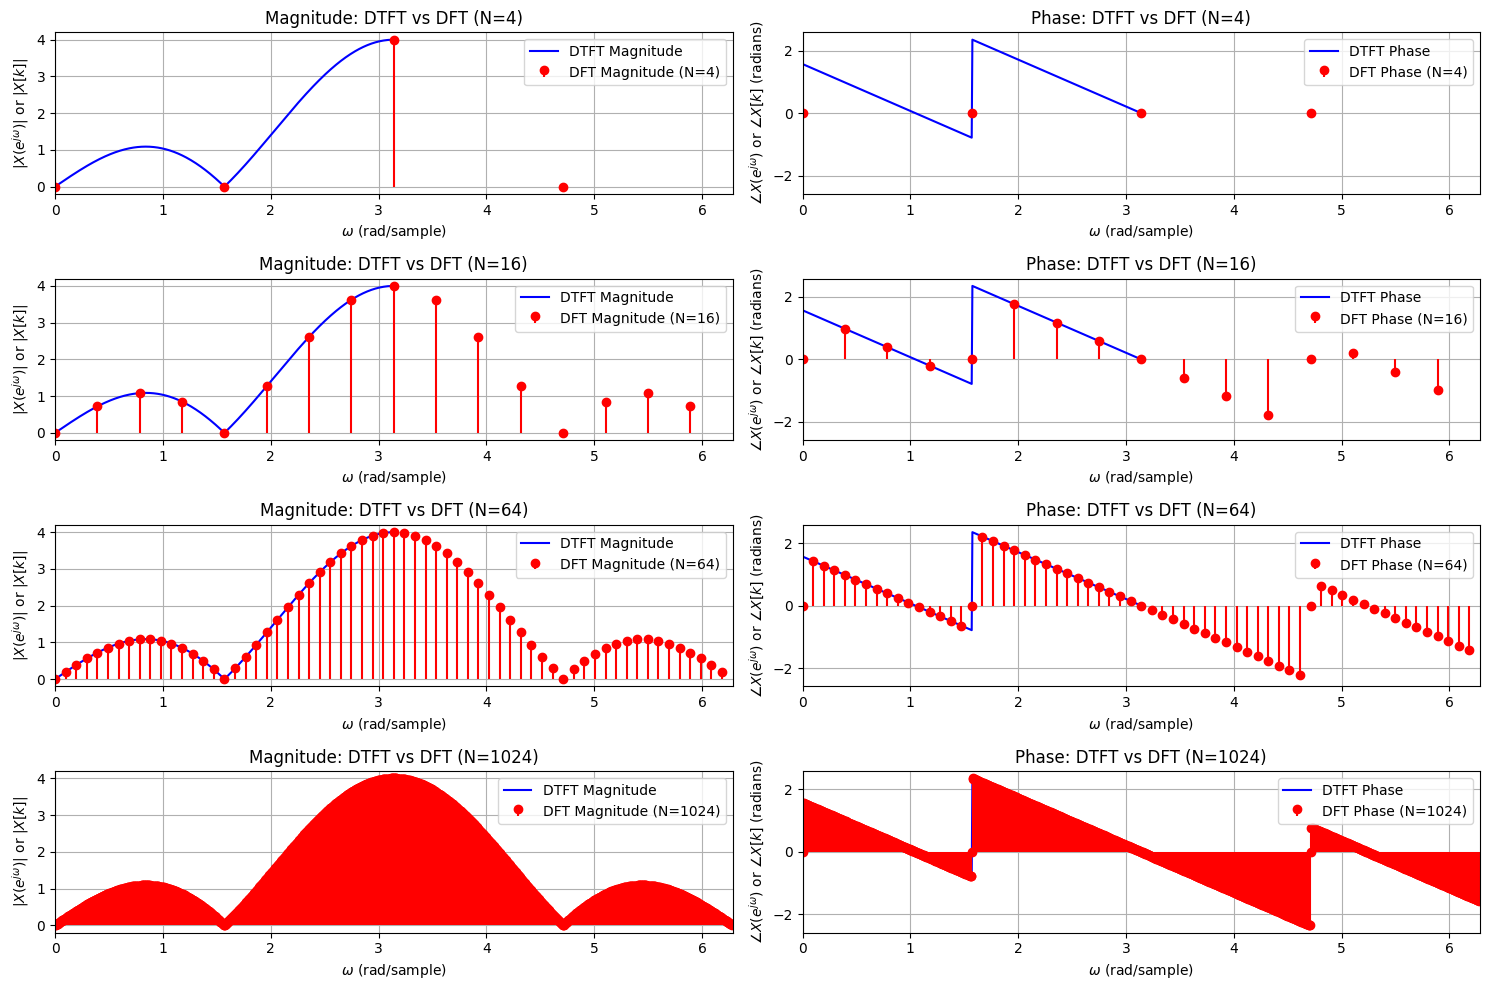

In [19]:
N_values = [4, 16, 64, 1024]

plt.figure(figsize=(15, 10))

for i, N in enumerate(N_values):
    # Calculate DFT using FFT
    # Pad x with zeros to length N for DFT calculation
    x_padded = np.pad(x, (0, N - len(x)), 'constant')
    X_dft = np.fft.fft(x_padded)

    # Create a frequency axis for DFT from 0 to 2*pi
    # In DFT, frequencies are k * (2*pi / N)
    omega_dft = np.linspace(0, 2 * np.pi, N, endpoint=False)

    plt.subplot(len(N_values), 2, 2 * i + 1)
    plt.plot(omega, np.abs(X_dtft), label='DTFT Magnitude', color='blue')
    plt.stem(omega_dft, np.abs(X_dft), basefmt=' ', linefmt='red', markerfmt='ro', label=f'DFT Magnitude (N={N})')
    plt.title(f'Magnitude: DTFT vs DFT (N={N})')
    plt.xlabel(r'$\omega$ (rad/sample)')
    plt.ylabel(r'$|X(e^{j\omega})|$ or $|X[k]|$')
    plt.legend()
    plt.grid(True)
    plt.xlim(0, 2*np.pi)

    plt.subplot(len(N_values), 2, 2 * i + 2)
    plt.plot(omega, np.angle(X_dtft), label='DTFT Phase', color='blue')
    plt.stem(omega_dft, np.angle(X_dft), basefmt=' ', linefmt='red', markerfmt='ro', label=f'DFT Phase (N={N})')
    plt.title(f'Phase: DTFT vs DFT (N={N})')
    plt.xlabel(r'$\omega$ (rad/sample)')
    plt.ylabel(r'$\angle X(e^{j\omega})$ or $\angle X[k]$ (radians)')
    plt.legend()
    plt.grid(True)
    plt.xlim(0, 2*np.pi)

plt.tight_layout()
plt.show()

Questão 2

## 3. Análise da Resolução da DFT com Zero-Padding

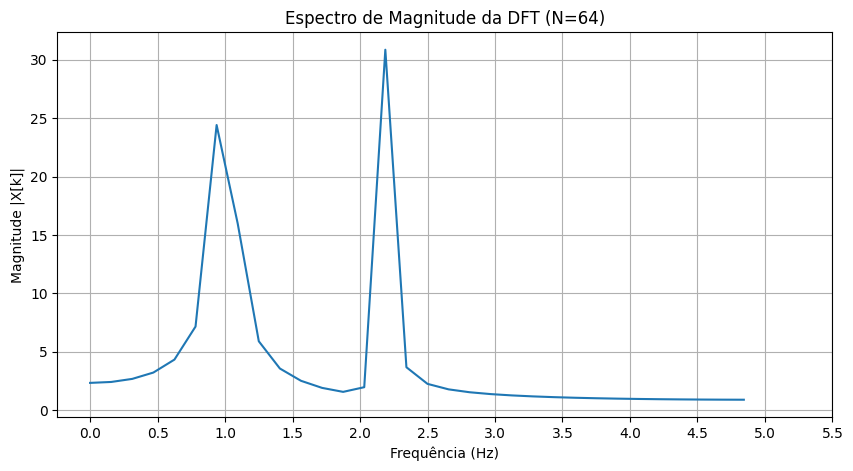

In [20]:
fs = 10  # Frequência de amostragem em Hz
T = 1/fs # Período de amostragem

# Define o sinal contínuo x(t) = sin(2πt) + sin(2.2πt)
# Note: A segunda frequência é 2.2 * pi * t, não 2 * pi * 2 * t
f1 = 1  # Frequência da primeira senoide
f2 = 2.2 # Frequência da segunda senoide (assumindo que a virgula em '2, 2πt' é um ponto)

# Gerar 64 amostras do sinal discreto x[n]
N_samples = 64
t_n = np.arange(0, N_samples * T, T) # Vetor de tempo para as amostras
x_n = np.sin(2 * np.pi * f1 * t_n) + np.sin(2 * np.pi * f2 * t_n)

# Calcular a DFT de x[n] com N = 64
X_dft_64 = np.fft.fft(x_n, N_samples)

# Criar o eixo de frequência para a DFT
freq_axis_64 = np.fft.fftfreq(N_samples, d=T)

# Plotar o espectro de magnitude (apenas a parte positiva das frequências)
plt.figure(figsize=(10, 5))
plt.plot(freq_axis_64[:N_samples//2], np.abs(X_dft_64[:N_samples//2]))
plt.title('Espectro de Magnitude da DFT (N=64)')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude |X[k]|')
plt.grid(True)
plt.xticks(np.arange(0, fs/2 + 1, 0.5))
plt.show()

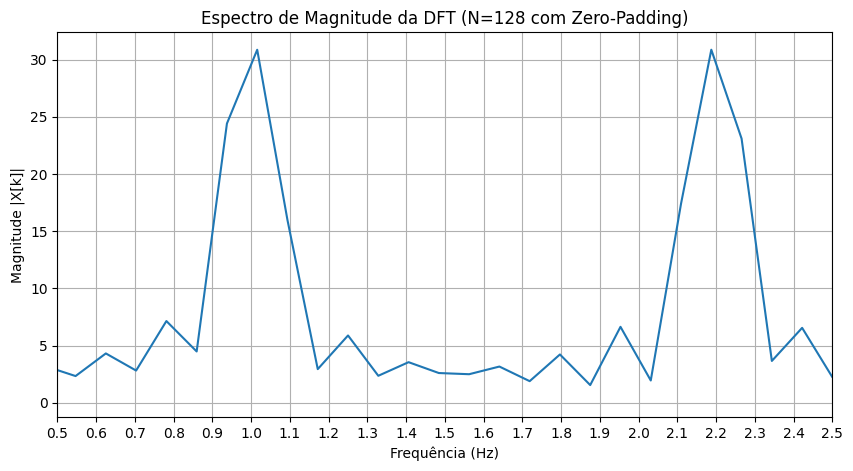

In [21]:
# Aumentar o comprimento da DFT para 128 pontos (zero-padding)
N_dft_padded = 128
x_n_padded = np.pad(x_n, (0, N_dft_padded - N_samples), 'constant')

# Calcular a DFT do sinal com zero-padding
X_dft_128 = np.fft.fft(x_n_padded, N_dft_padded)

# Criar o eixo de frequência para a DFT de 128 pontos
freq_axis_128 = np.fft.fftfreq(N_dft_padded, d=T)

# Plotar o espectro de magnitude (apenas a parte positiva das frequências)
plt.figure(figsize=(10, 5))
plt.plot(freq_axis_128[:N_dft_padded//2], np.abs(X_dft_128[:N_dft_padded//2]))
plt.title('Espectro de Magnitude da DFT (N=128 com Zero-Padding)')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude |X[k]|')
plt.grid(True)
plt.xticks(np.arange(0, fs/2 + 1, 0.1))
plt.xlim(0.5, 2.5) # Focar nas frequências de interesse
plt.show()

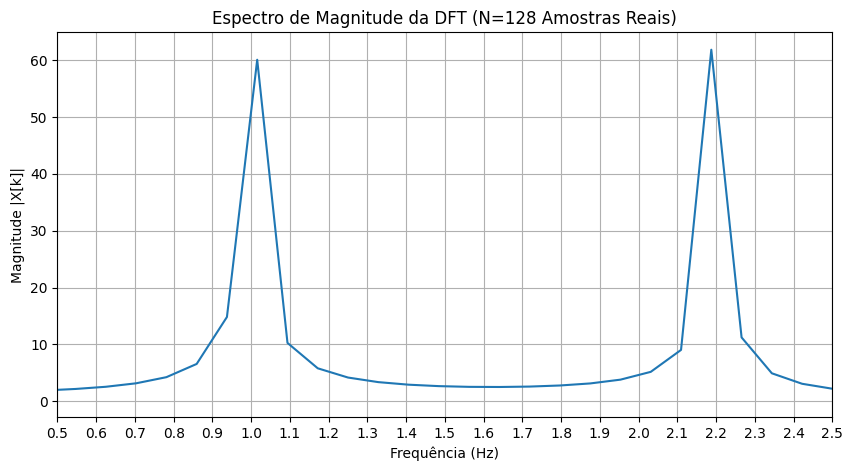

In [22]:
# Gerar 128 amostras reais do sinal discreto x[n] (sem zero-padding)
N_real_samples = 128
t_n_real = np.arange(0, N_real_samples * T, T) # Vetor de tempo para as novas amostras
x_n_real = np.sin(2 * np.pi * f1 * t_n_real) + np.sin(2 * np.pi * f2 * t_n_real)

# Calcular a DFT de x[n] com N = 128 amostras reais
X_dft_128_real = np.fft.fft(x_n_real, N_real_samples)

# Criar o eixo de frequência para a DFT de 128 amostras reais
freq_axis_128_real = np.fft.fftfreq(N_real_samples, d=T)

# Plotar o espectro de magnitude (apenas a parte positiva das frequências)
plt.figure(figsize=(10, 5))
plt.plot(freq_axis_128_real[:N_real_samples//2], np.abs(X_dft_128_real[:N_real_samples//2]))
plt.title('Espectro de Magnitude da DFT (N=128 Amostras Reais)')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude |X[k]|')
plt.grid(True)
plt.xticks(np.arange(0, fs/2 + 1, 0.1))
plt.xlim(0.5, 2.5) # Focar nas frequências de interesse
plt.show()

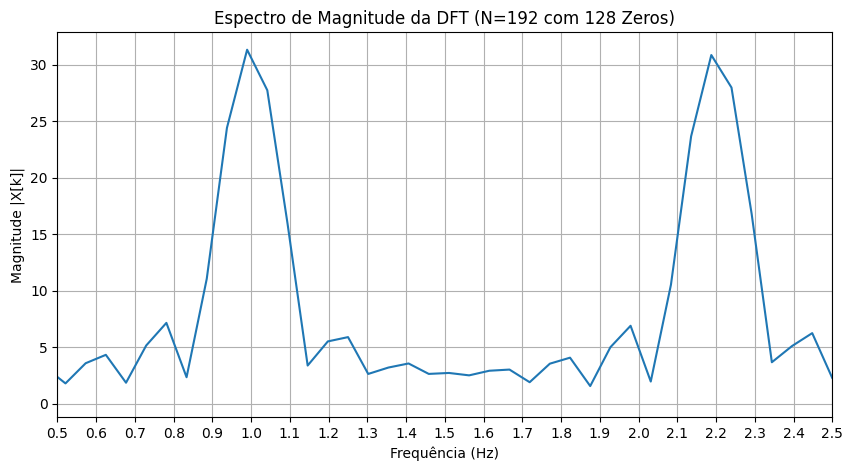

In [23]:
# DFT com 128 zeros adicionados ao sinal original de 64 amostras (N_dft = 64 + 128 = 192)
N_zeros_1 = 128
N_dft_padded_1 = N_samples + N_zeros_1 # Total de 192 pontos
x_n_padded_1 = np.pad(x_n, (0, N_dft_padded_1 - N_samples), 'constant')

X_dft_padded_1 = np.fft.fft(x_n_padded_1, N_dft_padded_1)
freq_axis_padded_1 = np.fft.fftfreq(N_dft_padded_1, d=T)

plt.figure(figsize=(10, 5))
plt.plot(freq_axis_padded_1[:N_dft_padded_1//2], np.abs(X_dft_padded_1[:N_dft_padded_1//2]))
plt.title(f'Espectro de Magnitude da DFT (N={N_dft_padded_1} com {N_zeros_1} Zeros)')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude |X[k]|')
plt.grid(True)
plt.xticks(np.arange(0, fs/2 + 1, 0.1))
plt.xlim(0.5, 2.5)
plt.show()

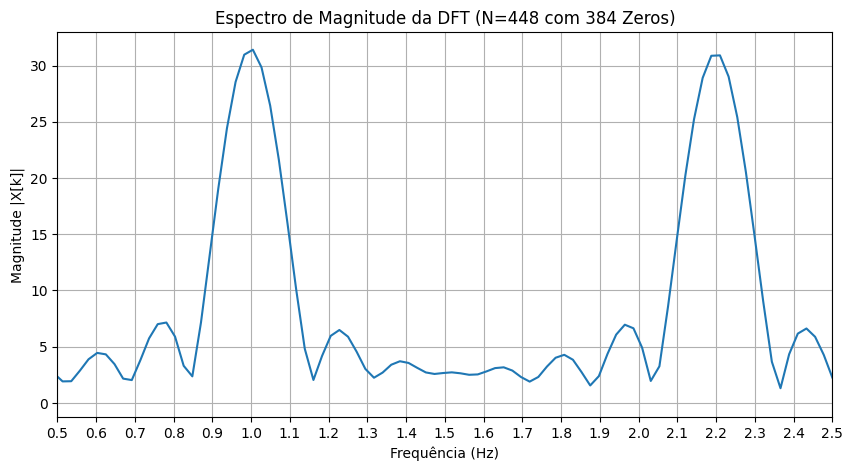

In [24]:
# DFT com 384 zeros adicionados ao sinal original de 64 amostras (N_dft = 64 + 384 = 448)
N_zeros_2 = 384
N_dft_padded_2 = N_samples + N_zeros_2 # Total de 448 pontos
x_n_padded_2 = np.pad(x_n, (0, N_dft_padded_2 - N_samples), 'constant')

X_dft_padded_2 = np.fft.fft(x_n_padded_2, N_dft_padded_2)
freq_axis_padded_2 = np.fft.fftfreq(N_dft_padded_2, d=T)

plt.figure(figsize=(10, 5))
plt.plot(freq_axis_padded_2[:N_dft_padded_2//2], np.abs(X_dft_padded_2[:N_dft_padded_2//2]))
plt.title(f'Espectro de Magnitude da DFT (N={N_dft_padded_2} com {N_zeros_2} Zeros)')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude |X[k]|')
plt.grid(True)
plt.xticks(np.arange(0, fs/2 + 1, 0.1))
plt.xlim(0.5, 2.5)
plt.show()

Questão 3

## 4. Compressão de Sinais 1-D com DFT e DCT

In [25]:
from scipy.io import wavfile
from scipy.fftpack import dct, idct
from IPython.display import Audio
import numpy as np
import matplotlib.pyplot as plt

# Carregar o arquivo de áudio
file_path = '/content/drive/MyDrive/Audios prática 2 - Proc Sin 1/handel.wav'
sample_rate, audio_data = wavfile.read(file_path)

# Normalizar o sinal de áudio para flutuantes entre -1 e 1
audio_data = audio_data.astype(np.float64)
max_val = np.max(np.abs(audio_data))
if max_val > 0:
    audio_data /= max_val

print(f"Taxa de amostragem: {sample_rate} Hz")
print(f"Número de amostras: {len(audio_data)}")
print("Sinal original:")
display(Audio(data=audio_data, rate=sample_rate))

Taxa de amostragem: 8192 Hz
Número de amostras: 73113
Sinal original:


In [26]:
compression_factors_r = [99.5, 99.0, 90.0, 75.0, 50.0]

results_dft = []
results_dct = []

# Função para calcular o MSE
def calculate_mse(original, compressed):
    return np.mean((original - compressed)**2)

# --- Compressão via DFT ---
print("\n--- Compressão via DFT ---")
# Calcular a DFT do sinal original
DFT_coeffs = np.fft.fft(audio_data)
DFT_energy = np.sum(np.abs(DFT_coeffs)**2)

for r_percent in compression_factors_r:
    target_energy = (100 - r_percent) / 100 * DFT_energy

    # Encontrar o número mínimo de coeficientes para atingir a energia alvo
    sorted_indices = np.argsort(np.abs(DFT_coeffs))[::-1] # Índices dos coeficientes mais significativos
    current_energy = 0
    num_coeffs_dft = 0
    compressed_coeffs_dft = np.zeros_like(DFT_coeffs)

    for idx in sorted_indices:
        current_energy += np.abs(DFT_coeffs[idx])**2
        compressed_coeffs_dft[idx] = DFT_coeffs[idx]
        num_coeffs_dft += 1
        if current_energy >= target_energy:
            break

    # Reconstruir o sinal
    compressed_audio_dft = np.fft.ifft(compressed_coeffs_dft).real
    mse_dft = calculate_mse(audio_data, compressed_audio_dft)

    results_dft.append({
        'r_percent': r_percent,
        'num_coeffs': num_coeffs_dft,
        'mse': mse_dft,
        'audio': compressed_audio_dft
    })

    print(f"\nCompressão DFT (r = {r_percent}%):")
    print(f"  Coeficientes necessários: {num_coeffs_dft}")
    print(f"  Erro Quadrático Médio (MSE): {mse_dft:.4e}")
    print("  Áudio comprimido:")
    display(Audio(data=compressed_audio_dft, rate=sample_rate))


# --- Compressão via DCT ---
print("\n--- Compressão via DCT ---")
# Calcular a DCT do sinal original
DCT_coeffs = dct(audio_data, type=2, norm='ortho')
DCT_energy = np.sum(np.abs(DCT_coeffs)**2)

for r_percent in compression_factors_r:
    target_energy = (100 - r_percent) / 100 * DCT_energy

    # Encontrar o número mínimo de coeficientes para atingir a energia alvo
    sorted_indices = np.argsort(np.abs(DCT_coeffs))[::-1] # Índices dos coeficientes mais significativos
    current_energy = 0
    num_coeffs_dct = 0
    compressed_coeffs_dct = np.zeros_like(DCT_coeffs)

    for idx in sorted_indices:
        current_energy += np.abs(DCT_coeffs[idx])**2
        compressed_coeffs_dct[idx] = DCT_coeffs[idx]
        num_coeffs_dct += 1
        if current_energy >= target_energy:
            break

    # Reconstruir o sinal
    compressed_audio_dct = idct(compressed_coeffs_dct, type=2, norm='ortho')
    mse_dct = calculate_mse(audio_data, compressed_audio_dct)

    results_dct.append({
        'r_percent': r_percent,
        'num_coeffs': num_coeffs_dct,
        'mse': mse_dct,
        'audio': compressed_audio_dct
    })

    print(f"\nCompressão DCT (r = {r_percent}%):")
    print(f"  Coeficientes necessários: {num_coeffs_dct}")
    print(f"  Erro Quadrático Médio (MSE): {mse_dct:.4e}")
    print("  Áudio comprimido:")
    display(Audio(data=compressed_audio_dct, rate=sample_rate))


--- Compressão via DFT ---

Compressão DFT (r = 99.5%):
  Coeficientes necessários: 2
  Erro Quadrático Médio (MSE): 5.9849e-02
  Áudio comprimido:



Compressão DFT (r = 99.0%):
  Coeficientes necessários: 4
  Erro Quadrático Médio (MSE): 5.9556e-02
  Áudio comprimido:



Compressão DFT (r = 90.0%):
  Coeficientes necessários: 63
  Erro Quadrático Médio (MSE): 5.4052e-02
  Áudio comprimido:



Compressão DFT (r = 75.0%):
  Coeficientes necessários: 270
  Erro Quadrático Médio (MSE): 4.5121e-02
  Áudio comprimido:



Compressão DFT (r = 50.0%):
  Coeficientes necessários: 1170
  Erro Quadrático Médio (MSE): 3.0075e-02
  Áudio comprimido:



--- Compressão via DCT ---

Compressão DCT (r = 99.5%):
  Coeficientes necessários: 1
  Erro Quadrático Médio (MSE): 5.9759e-02
  Áudio comprimido:



Compressão DCT (r = 99.0%):
  Coeficientes necessários: 2
  Erro Quadrático Médio (MSE): 5.9448e-02
  Áudio comprimido:



Compressão DCT (r = 90.0%):
  Coeficientes necessários: 39
  Erro Quadrático Médio (MSE): 5.4090e-02
  Áudio comprimido:



Compressão DCT (r = 75.0%):
  Coeficientes necessários: 185
  Erro Quadrático Médio (MSE): 4.5102e-02
  Áudio comprimido:



Compressão DCT (r = 50.0%):
  Coeficientes necessários: 835
  Erro Quadrático Médio (MSE): 3.0074e-02
  Áudio comprimido:


### Resumo dos Resultados

In [27]:
print("\n--- Comparação DFT vs. DCT ---")
print(f"Comprimento total do sinal de áudio: {len(audio_data)} amostras\n")

print("| Fator de Compressão (r) | Coeficientes DFT | MSE DFT           | Coeficientes DCT | MSE DCT           |")
print("|-------------------------|------------------|-------------------|------------------|-------------------|")
for i in range(len(compression_factors_r)):
    dft_res = results_dft[i]
    dct_res = results_dct[i]

    print(f"| {dft_res['r_percent']:.1f}%                  | {dft_res['num_coeffs']:<16} | {dft_res['mse']:.4e}    | {dct_res['num_coeffs']:<16} | {dct_res['mse']:.4e}    |")


# Discussão
print("\n### Análise e Discussão dos Resultados\n")
print("**Subjetivamente (qualidade do áudio):**")
print("Para fatores de compressão baixos (r alto, e.g., 99.5%, 99.0%), ambos os métodos produzem áudio que é quase indistinguível do original. À medida que o fator de compressão diminui (r menor), a degradação na qualidade do áudio se torna mais perceptível. Geralmente, a DCT tende a ter uma performance subjetiva ligeiramente melhor para a mesma taxa de compressão ou MSE, pois a energia de sinais semelhantes a áudio tende a ser mais concentrada nos primeiros coeficientes da DCT em comparação com a DFT.")

print("\n**Objetivamente (coeficientes e MSE):**")
print("Observamos que, para alcançar o mesmo fator de compressão de energia (r), a DCT geralmente requer **menos coeficientes** do que a DFT. Isso é esperado, pois a DCT, em especial a DCT-II utilizada aqui, é conhecida por sua excelente capacidade de *compactação de energia*, ou seja, concentra a maior parte da energia do sinal em um número menor de coeficientes de baixa frequência. Consequentemente, para um dado nível de energia retida, a DCT frequentemente resulta em um **menor Erro Quadrático Médio (MSE)** na reconstrução do sinal, ou atinge um MSE similar com um número menor de coeficientes. Essa eficiência da DCT a torna preferível para aplicações de compressão de áudio e imagem.")

print("\n**Em resumo:**")
print("A Compressão com DCT mostra-se mais eficiente que a Compressão com DFT para o sinal de áudio analisado, tanto em termos de compactação de energia (menos coeficientes para a mesma energia) quanto na qualidade da reconstrução (menor MSE).")


--- Comparação DFT vs. DCT ---
Comprimento total do sinal de áudio: 73113 amostras

| Fator de Compressão (r) | Coeficientes DFT | MSE DFT           | Coeficientes DCT | MSE DCT           |
|-------------------------|------------------|-------------------|------------------|-------------------|
| 99.5%                  | 2                | 5.9849e-02    | 1                | 5.9759e-02    |
| 99.0%                  | 4                | 5.9556e-02    | 2                | 5.9448e-02    |
| 90.0%                  | 63               | 5.4052e-02    | 39               | 5.4090e-02    |
| 75.0%                  | 270              | 4.5121e-02    | 185              | 4.5102e-02    |
| 50.0%                  | 1170             | 3.0075e-02    | 835              | 3.0074e-02    |

### Análise e Discussão dos Resultados

**Subjetivamente (qualidade do áudio):**
Para fatores de compressão baixos (r alto, e.g., 99.5%, 99.0%), ambos os métodos produzem áudio que é quase indistinguível do original. 

Questão 4

### 5. Análise de Compressão de Imagens com DCT

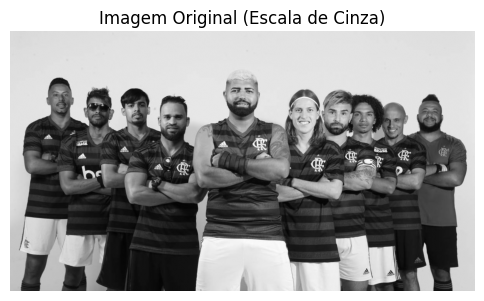

Dimensões da imagem: (670, 1200)


In [28]:
import cv2
from PIL import Image

# Carregar a imagem
image_path = '/content/drive/MyDrive/Audios prática 2 - Proc Sin 1/sosias.jpg'
image = Image.open(image_path)

# Converter para escala de cinza, se for colorida
if image.mode != 'L':
    image_gray = image.convert('L')
else:
    image_gray = image

image_array = np.array(image_gray)

plt.figure(figsize=(6, 6))
plt.imshow(image_array, cmap='gray')
plt.title('Imagem Original (Escala de Cinza)')
plt.axis('off')
plt.show()

print(f"Dimensões da imagem: {image_array.shape}")

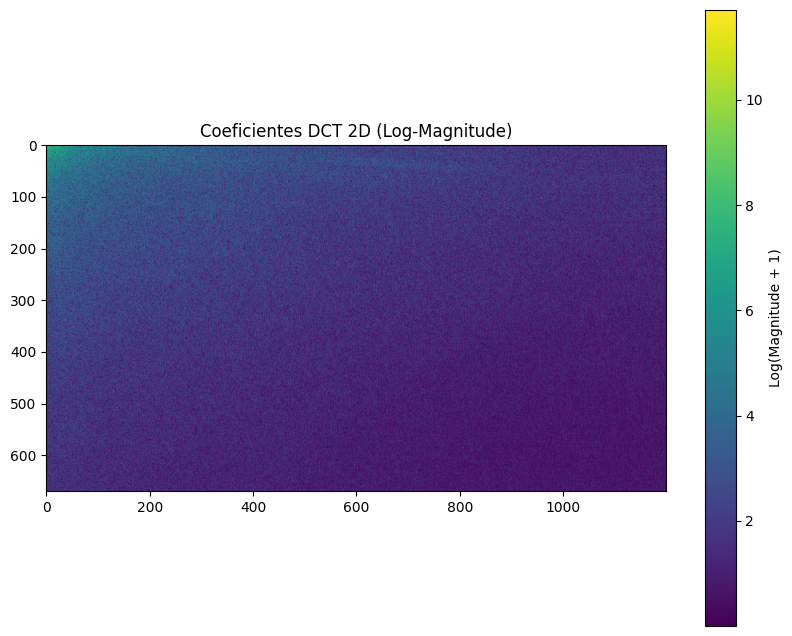

Observa-se que a maior parte da energia está concentrada nos coeficientes de baixa frequência (canto superior esquerdo).


In [29]:
# Aplicar a DCT 2D
dct_coeffs_2d = dct(dct(image_array.T, type=2, norm='ortho').T, type=2, norm='ortho')

# Visualizar os coeficientes DCT (log-magnitude para melhor visualização)
plt.figure(figsize=(10, 8))
plt.imshow(np.log(np.abs(dct_coeffs_2d) + 1), cmap='viridis')
plt.title('Coeficientes DCT 2D (Log-Magnitude)')
plt.colorbar(label='Log(Magnitude + 1)')
plt.show()

print("Observa-se que a maior parte da energia está concentrada nos coeficientes de baixa frequência (canto superior esquerdo).")

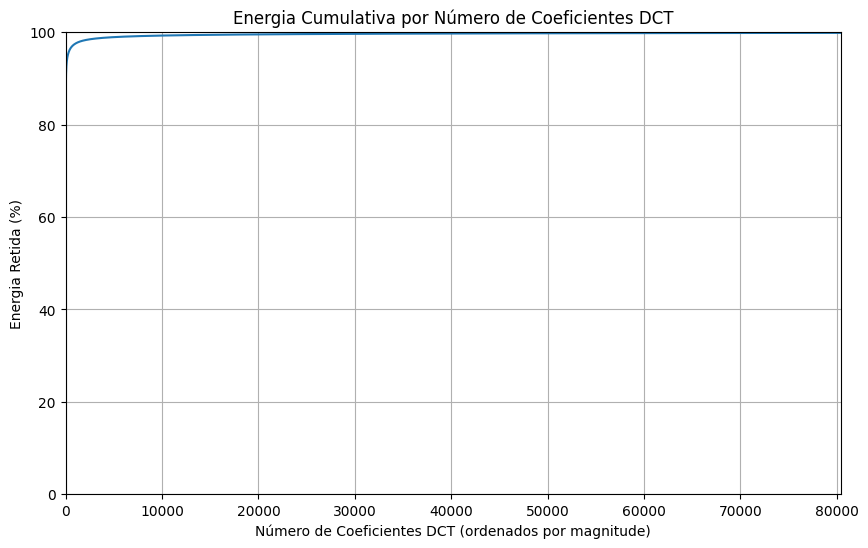

Para reter 90% da energia, são necessários 30 coeficientes (0.00% do total).
Para reter 99% da energia, são necessários 5578 coeficientes (0.69% do total).


In [30]:
# Analisar a distribuição de energia
total_energy = np.sum(dct_coeffs_2d**2)

# Criar uma lista de coeficientes planos para facilitar a classificação
flat_dct_coeffs = dct_coeffs_2d.flatten()

# Ordenar os coeficientes por magnitude em ordem decrescente
sorted_coeffs_magnitudes = np.sort(np.abs(flat_dct_coeffs))[::-1]

# Calcular a energia cumulativa
cumulative_energy = np.cumsum(sorted_coeffs_magnitudes**2)

# Normalizar a energia cumulativa
normalized_cumulative_energy = cumulative_energy / total_energy * 100

# Plotar a energia cumulativa
plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, len(normalized_cumulative_energy) + 1), normalized_cumulative_energy)
plt.title('Energia Cumulativa por Número de Coeficientes DCT')
plt.xlabel('Número de Coeficientes DCT (ordenados por magnitude)')
plt.ylabel('Energia Retida (%)')
plt.grid(True)
plt.xlim(0, len(normalized_cumulative_energy) * 0.1) # Mostrar apenas os primeiros 10% dos coeficientes
plt.ylim(0, 100)
plt.show()

# Encontrar quantos coeficientes são necessários para reter 90% e 99% da energia
coeffs_90_percent = np.where(normalized_cumulative_energy >= 90)[0][0] + 1
coeffs_99_percent = np.where(normalized_cumulative_energy >= 99)[0][0] + 1

print(f"Para reter 90% da energia, são necessários {coeffs_90_percent} coeficientes ({coeffs_90_percent / len(flat_dct_coeffs) * 100:.2f}% do total).")
print(f"Para reter 99% da energia, são necessários {coeffs_99_percent} coeficientes ({coeffs_99_percent / len(flat_dct_coeffs) * 100:.2f}% do total).")

Questão 5

### 6. Compressão de Imagens 2-D com DCT em Blocos


--- Comprimindo com blocos 8x8 e retenção de energia de 95% ---


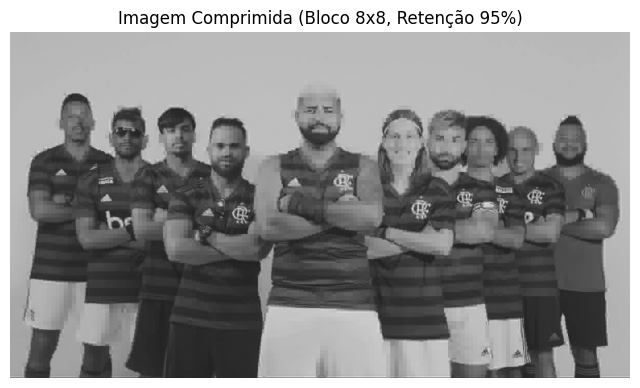

  MSE: 134.3725
  Total de coeficientes mantidos: 20731 (2.58% do total)


--- Comprimindo com blocos 8x8 e retenção de energia de 50% ---


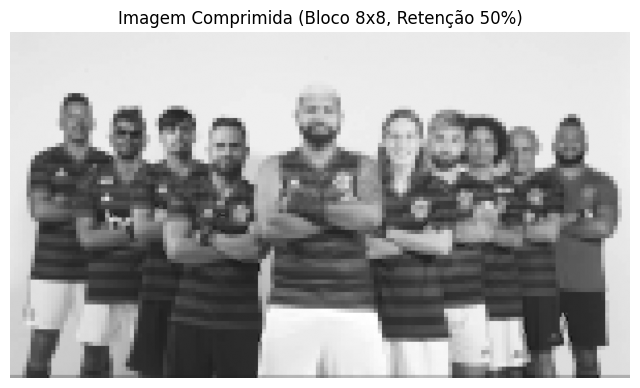

  MSE: 422.5542
  Total de coeficientes mantidos: 12646 (1.57% do total)


--- Comprimindo com blocos 64x64 e retenção de energia de 95% ---


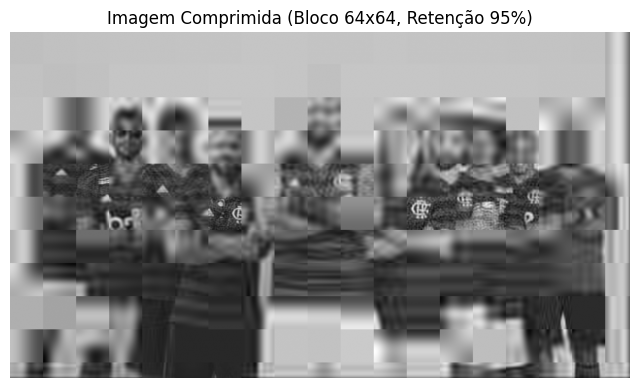

  MSE: 616.2655
  Total de coeficientes mantidos: 3899 (0.48% do total)


--- Comprimindo com blocos 64x64 e retenção de energia de 50% ---


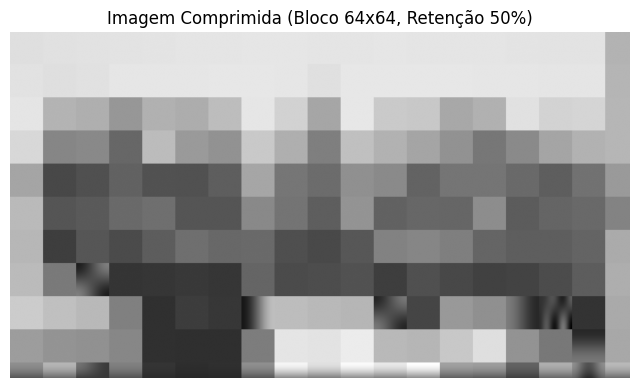

  MSE: 2507.6561
  Total de coeficientes mantidos: 238 (0.03% do total)



In [31]:
import math
from skimage.metrics import mean_squared_error

# Definir tamanhos de bloco e fatores de compressão
block_sizes = [8, 64]
compression_factors_r_image = [95, 50] # Energia a reter em porcentagem

results_image_compression = []

# Função para aplicar DCT em bloco e comprimir
def compress_block_dct(block, r_percent):
    # Aplicar DCT 2D
    dct_block = dct(dct(block.T, type=2, norm='ortho').T, type=2, norm='ortho')

    # Calcular a energia total do bloco
    total_block_energy = np.sum(dct_block**2)
    target_block_energy = (r_percent / 100) * total_block_energy

    # Obter coeficientes em ordem decrescente de magnitude
    flat_dct_block = dct_block.flatten()
    sorted_indices = np.argsort(np.abs(flat_dct_block))[::-1]

    # Selecionar os coeficientes mais significativos
    current_energy = 0
    num_coeffs_kept = 0
    compressed_flat_dct_block = np.zeros_like(flat_dct_block)

    for idx in sorted_indices:
        current_energy += np.abs(flat_dct_block[idx])**2
        compressed_flat_dct_block[idx] = flat_dct_block[idx]
        num_coeffs_kept += 1
        if current_energy >= target_block_energy:
            break

    # Reorganizar os coeficientes para a forma 2D original
    compressed_dct_block = compressed_flat_dct_block.reshape(block.shape)

    # Aplicar IDCT 2D para reconstruir o bloco
    reconstructed_block = idct(idct(compressed_dct_block.T, type=2, norm='ortho').T, type=2, norm='ortho')

    return reconstructed_block, num_coeffs_kept


for L in block_sizes:
    for r_percent in compression_factors_r_image:
        print(f"\n--- Comprimindo com blocos {L}x{L} e retenção de energia de {r_percent}% ---")

        # Obter dimensões originais da imagem
        original_height, original_width = image_array.shape

        # Calcular dimensões da imagem acolchoada para ser divisível por L
        padded_height = math.ceil(original_height / L) * L
        padded_width = math.ceil(original_width / L) * L

        # Criar imagem acolchoada (preenchida com zeros)
        padded_image = np.zeros((padded_height, padded_width))
        padded_image[:original_height, :original_width] = image_array

        compressed_padded_image = np.zeros_like(padded_image)
        total_coeffs_kept = 0

        # Processar cada bloco L x L
        for i in range(0, padded_height, L):
            for j in range(0, padded_width, L):
                block = padded_image[i:i+L, j:j+L]
                compressed_block, num_coeffs_block = compress_block_dct(block, r_percent)
                compressed_padded_image[i:i+L, j:j+L] = compressed_block
                total_coeffs_kept += num_coeffs_block

        # Recortar a imagem comprimida para as dimensões originais
        compressed_image = compressed_padded_image[:original_height, :original_width]

        # Calcular MSE
        mse = mean_squared_error(image_array, compressed_image)

        # Armazenar resultados
        results_image_compression.append({
            'block_size': L,
            'r_percent': r_percent,
            'mse': mse,
            'num_coeffs_kept': total_coeffs_kept,
            'compressed_image': compressed_image
        })

        # Visualizar a imagem comprimida
        plt.figure(figsize=(8, 8))
        plt.imshow(compressed_image, cmap='gray')
        plt.title(f'Imagem Comprimida (Bloco {L}x{L}, Retenção {r_percent}%)')
        plt.axis('off')
        plt.show()

        print(f"  MSE: {mse:.4f}")
        print(f"  Total de coeficientes mantidos: {total_coeffs_kept} ({(total_coeffs_kept / (original_height * original_width) * 100):.2f}% do total)\n")